# 📊 04 — Análisis y Visualización del Mercado Laboral Tech en España
**Cliente:** DataTalent Solutions S.L.  
**Versión:** 2.0 · Datos limpios desde `02_cleaning.ipynb`  
**Librerías:** `pandas` · `numpy` · `matplotlib` · `seaborn` · `plotly` · `squarify` · `scipy` · `statsmodels`

---

### Estructura del análisis

| Bloque | Contenido |
|--------|-----------|
| 0 | Configuración, carga de datos y calidad |
| 1 | Distribución y volumen de vacantes |
| 2 | Análisis retributivo y salarial |
| 3 | Mapas de calor y correlaciones |
| 4 | Stack tecnológico y brecha Used vs Wanted |
| 5 | Análisis estadístico avanzado |
| 6 | Visualizaciones interactivas (Plotly) |
| 7 | Conclusiones y exportación |

> **Instrucciones:** Si tienes los CSVs limpios de `02_cleaning.ipynb` colócalos en `data/clean/`. Si no, el notebook genera un dataset simulado realista de 600 registros.


## 🛠️ Bloque 0 — Configuración e Importaciones

In [2]:
# ============================================================
# INSTALACIÓN (descomentar si es necesario en Colab)
# ============================================================
!pip install -q pandas numpy matplotlib seaborn plotly squarify scipy statsmodels kaleido

# ============================================================
# IMPORTACIONES
# ============================================================
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import squarify
from scipy import stats
from scipy.stats import kruskal, mannwhitneyu
import statsmodels.api as sm

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# ============================================================
# PALETA Y ESTILO CORPORATIVO
# ============================================================
PALETA = {
    'primary':   '#1A365D',
    'secondary': '#2B6CB0',
    'accent':    '#4299E1',
    'warm':      '#ED8936',
    'success':   '#48BB78',
    'muted':     '#A0AEC0',
    'dark':      '#171923',
    'light':     '#EBF8FF',
}
PALETTE_LIST = list(PALETA.values())

sns.set_theme(style='whitegrid', palette=PALETTE_LIST)
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 15,
    'axes.titleweight': 'bold',
    'figure.titlesize': 18,
    'figure.titleweight': 'bold',
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': 'white',
    'axes.facecolor': '#FAFAFA',
})

os.makedirs('images', exist_ok=True)
print("✅ Entorno configurado correctamente.")
print("📁 Carpeta 'images/' lista para exportar gráficos.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 3.5 MB/s eta 0:00:00
✅ Entorno configurado correctamente.
📁 Carpeta 'images/' lista para exportar gráficos.


### 📂 Carga de datos limpios

Los datos provienen de `02_cleaning.ipynb`. Se intenta cargar `jobs_all_clean.csv`, `technology_rankings_used.csv` y `technology_rankings_wanted.csv`. Si no existen, se genera un dataset simulado completo.


In [3]:
# ============================================================
# CARGA O SIMULACIÓN DE DATOS
# ============================================================

def simular_dataset(n=600, seed=42):
    """Genera dataset sintético realista para pruebas."""
    np.random.seed(seed)
    roles     = ['Data Analyst', 'Data Scientist', 'Data Engineer', 'BI Analyst', 'ML Engineer']
    ciudades  = ['Madrid', 'Barcelona', 'Remoto', 'Valencia', 'Sevilla', 'Bilbao', 'Málaga']
    modos     = ['Presencial', 'Híbrido', 'Remoto']
    senio     = ['Junior', 'Mid', 'Senior']
    sectores  = ['Fintech', 'Consultoría', 'E-commerce', 'Salud', 'Telecomunicaciones', 'Seguros']
    fuentes   = ['jobs_clean', 'tecno_jobs_clean']
    skills    = ['Python','SQL','Power BI','AWS','Excel','Tableau','Spark','Databricks','Docker','Git']

    df = pd.DataFrame({
        'job_title':        np.random.choice(roles,    n, p=[0.30, 0.25, 0.20, 0.15, 0.10]),
        'city_clean':       np.random.choice(ciudades, n, p=[0.35, 0.25, 0.12, 0.10, 0.08, 0.06, 0.04]),
        'remote_modality':  np.random.choice(modos,    n, p=[0.20, 0.50, 0.30]),
        'seniority':        np.random.choice(senio,    n, p=[0.30, 0.50, 0.20]),
        'sector':           np.random.choice(sectores, n, p=[0.25, 0.25, 0.20, 0.15, 0.10, 0.05]),
        'source_dataset':   np.random.choice(fuentes,  n, p=[0.55, 0.45]),
        'experience_years': np.random.randint(0, 12, n),
    })

    # Salarios por seniority
    sal = np.random.normal(40000, 14000, n).astype(int)
    df['salary_clean'] = sal
    df.loc[df['seniority']=='Junior', 'salary_clean'] = df.loc[df['seniority']=='Junior','salary_clean'].clip(18000, 32000)
    df.loc[df['seniority']=='Mid',    'salary_clean'] = df.loc[df['seniority']=='Mid',   'salary_clean'].clip(30000, 52000)
    df.loc[df['seniority']=='Senior', 'salary_clean'] = df.loc[df['seniority']=='Senior','salary_clean'].clip(48000, 85000)

    # Columna de outlier
    q1, q3 = df['salary_clean'].quantile([0.25, 0.75])
    iqr = q3 - q1
    df['salary_clean_outlier'] = (df['salary_clean'] < q1 - 1.5*iqr) | (df['salary_clean'] > q3 + 1.5*iqr)

    # Skills binarias
    for s in skills:
        df[s] = np.random.choice([0,1], n, p=[0.60, 0.40])

    return df


def simular_rankings(n_techs=15, seed=42):
    """Genera rankings de tecnologías simulados."""
    np.random.seed(seed)
    techs = ['Python','SQL','JavaScript','Java','TypeScript','C#','Go','Rust',
             'Kotlin','Swift','R','Scala','PHP','C++','Ruby']
    pct_used   = np.sort(np.random.uniform(10, 90, n_techs))[::-1]
    pct_wanted = np.sort(np.random.uniform(8, 85, n_techs))[::-1]
    df_used = pd.DataFrame({'technology': techs[:n_techs], 'pct': pct_used, 'type': 'HaveWorkedWith'})
    df_want = pd.DataFrame({'technology': techs[:n_techs], 'pct': pct_wanted, 'type': 'WantToWorkWith'})
    return df_used, df_want


# ── Intentar cargar datos reales ──
try:
    df = pd.read_csv('data/clean/jobs_all_clean.csv')
    print(f"✅ jobs_all_clean.csv cargado → {df.shape}")
    DATOS_REALES = True
except FileNotFoundError:
    df = simular_dataset()
    print(f"⚠️  Dataset simulado generado → {df.shape}")
    DATOS_REALES = False

try:
    df_used   = pd.read_csv('data/clean/technology_rankings_used.csv')
    df_wanted = pd.read_csv('data/clean/technology_rankings_wanted.csv')
    print("✅ Rankings tecnológicos cargados.")
    TECH_REAL = True
except FileNotFoundError:
    df_used, df_wanted = simular_rankings()
    print("⚠️  Rankings tecnológicos simulados.")
    TECH_REAL = False

# ── Columnas de skills disponibles ──
SKILLS_COLS = ['Python','SQL','Power BI','AWS','Excel','Tableau','Spark','Databricks','Docker','Git']
SKILLS_COLS = [s for s in SKILLS_COLS if s in df.columns]

print(f"\n📋 Columnas disponibles: {df.columns.tolist()}")
print(f"\n📊 Resumen estadístico básico:")
df.describe(include='all').T

⚠️  Dataset simulado generado → (600, 19)
⚠️  Rankings tecnológicos simulados.

📋 Columnas disponibles: ['job_title', 'city_clean', 'remote_modality', 'seniority', 'sector', 'source_dataset', 'experience_years', 'salary_clean', 'salary_clean_outlier', 'Python', 'SQL', 'Power BI', 'AWS', 'Excel', 'Tableau', 'Spark', 'Databricks', 'Docker', 'Git']

📊 Resumen estadístico básico:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
job_title,600,5,Data Analyst,181,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city_clean,600,7,Madrid,221,NaN,NaN,NaN,NaN,NaN,NaN,NaN
remote_modality,600,3,Híbrido,303,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seniority,600,3,Mid,307,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sector,600,6,Consultoría,158,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source_dataset,600,2,jobs_clean,323,NaN,NaN,NaN,NaN,NaN,NaN,NaN
experience_years,600.00,NaN,NaN,NaN,5.54,3.42,0.00,3.00,6.00,9.00,11.00
salary_clean,600.00,NaN,NaN,NaN,39507.47,10507.22,18000.00,32000.00,35824.00,48000.00,76869.00
salary_clean_outlier,600,2,False,597,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Python,600.00,NaN,NaN,NaN,0.38,0.49,0.00,0.00,0.00,1.00,1.00


### 🔍 Calidad del dataset

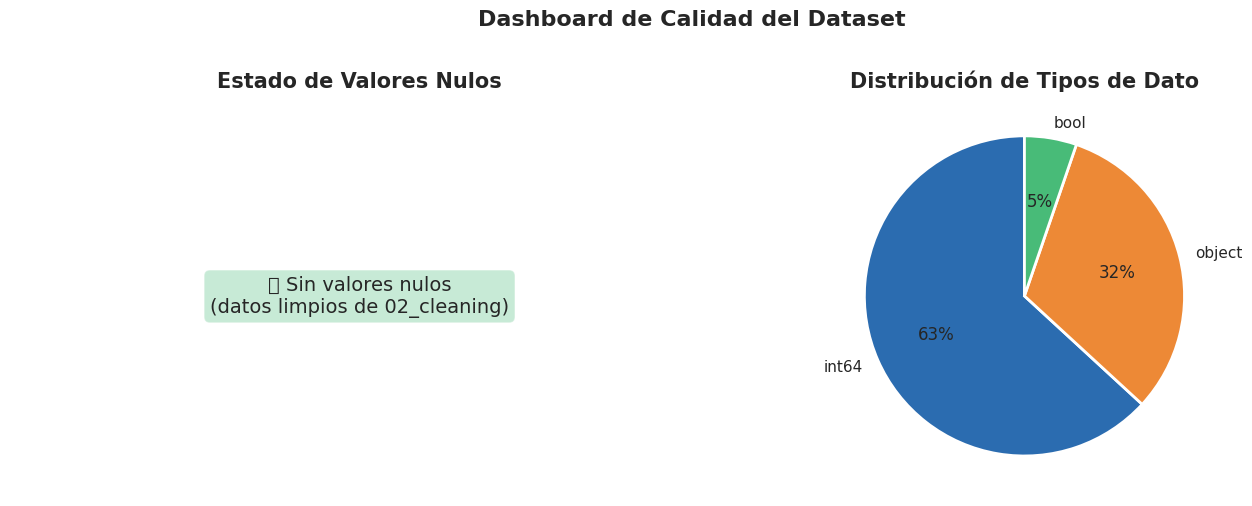


📊 Shape: 600 filas × 19 columnas
💾 Memoria: 272.6 KB


,Tipo,Nulos,Nulos (%),Únicos
job_title,object,0,0.00,5
city_clean,object,0,0.00,7
remote_modality,object,0,0.00,3
seniority,object,0,0.00,3
sector,object,0,0.00,6
source_dataset,object,0,0.00,2
experience_years,int64,0,0.00,12
salary_clean,int64,0,0.00,257
salary_clean_outlier,bool,0,0.00,2
Python,int64,0,0.00,2


In [4]:
# ============================================================
# DASHBOARD DE CALIDAD DE DATOS
# ============================================================
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)
tipos = df.dtypes

calidad = pd.DataFrame({
    'Tipo': tipos,
    'Nulos': nulos,
    'Nulos (%)': nulos_pct,
    'Únicos': df.nunique(),
}).sort_values('Nulos (%)', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Dashboard de Calidad del Dataset', fontsize=16, fontweight='bold', y=1.01)

# Mapa de calor de nulos
if nulos.sum() > 0:
    missing_matrix = df.isnull().astype(int)
    sns.heatmap(missing_matrix.T, cmap='YlOrRd', cbar=False, ax=axes[0],
                yticklabels=True, xticklabels=False)
    axes[0].set_title('Mapa de Valores Nulos por Fila')
    axes[0].set_xlabel('Registros')
else:
    axes[0].text(0.5, 0.5, '✅ Sin valores nulos\n(datos limpios de 02_cleaning)',
                 ha='center', va='center', fontsize=14, transform=axes[0].transAxes,
                 bbox=dict(boxstyle='round', facecolor=PALETA['success'], alpha=0.3))
    axes[0].set_title('Estado de Valores Nulos')
    axes[0].axis('off')

# Distribución de tipos
tipo_counts = df.dtypes.value_counts()
colors = [PALETA['secondary'], PALETA['warm'], PALETA['success']][:len(tipo_counts)]
axes[1].pie(tipo_counts.values, labels=[str(t) for t in tipo_counts.index],
            autopct='%1.0f%%', colors=colors, startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Distribución de Tipos de Dato')

plt.tight_layout()
plt.savefig('images/00_calidad_datos.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"\n📊 Shape: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"💾 Memoria: {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
display(calidad[calidad['Nulos'] > 0] if calidad['Nulos'].sum() > 0 else calidad.head(10))

## 📍 Bloque 1 — Distribución y Volumen de Vacantes

Análisis de dónde provienen las ofertas, bajo qué modalidades se publican y qué niveles de seniority son más demandados.


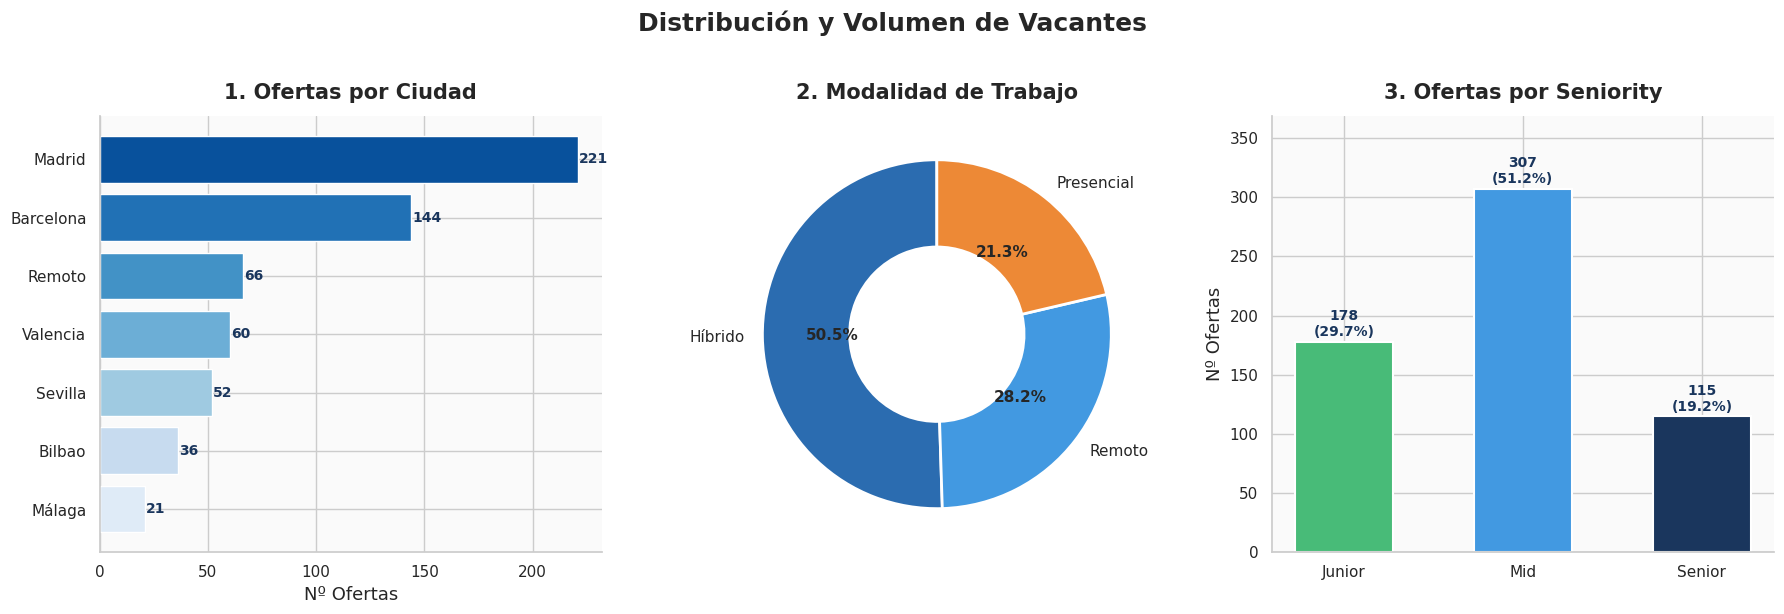

✅ Gráficos 1-3 generados.


In [5]:
# ============================================================
# BLOQUE 1: DISTRIBUCIÓN Y VOLUMEN (Gráficos 1-3)
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Distribución y Volumen de Vacantes', fontsize=18, fontweight='bold', y=1.02)

# ── G1: Ofertas por ciudad ──
if 'city_clean' in df.columns:
    city_col = 'city_clean'
elif 'city' in df.columns:
    city_col = 'city'
else:
    city_col = None

if city_col:
    city_counts = df[city_col].value_counts().head(8)
    bars = axes[0].barh(city_counts.index, city_counts.values,
                        color=sns.color_palette('Blues_r', len(city_counts)))
    axes[0].set_title('1. Ofertas por Ciudad', pad=12)
    axes[0].set_xlabel('Nº Ofertas')
    for bar, val in zip(bars, city_counts.values):
        axes[0].text(val + 0.5, bar.get_y() + bar.get_height()/2,
                     f'{val:,}', va='center', fontweight='bold', fontsize=10, color=PALETA['primary'])
    axes[0].invert_yaxis()

# ── G2: Modalidad (Donut) ──
if 'remote_modality' in df.columns:
    mod_counts = df['remote_modality'].value_counts(normalize=True) * 100
    colors_mod = [PALETA['secondary'], PALETA['accent'], PALETA['warm']]
    wedges, texts, autotexts = axes[1].pie(
        mod_counts.values, labels=mod_counts.index,
        autopct='%1.1f%%', startangle=90,
        colors=colors_mod[:len(mod_counts)],
        wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2),
        textprops={'fontsize': 11}
    )
    for at in autotexts:
        at.set_fontweight('bold')
    axes[1].set_title('2. Modalidad de Trabajo', pad=12)

# ── G3: Seniority (barras con anotaciones) ──
if 'seniority' in df.columns:
    senio_order = ['Junior', 'Mid', 'Senior']
    senio_counts = df['seniority'].value_counts().reindex(senio_order).dropna()
    colors_s = [PALETA['success'], PALETA['accent'], PALETA['primary']]
    bars3 = axes[2].bar(senio_counts.index, senio_counts.values,
                        color=colors_s[:len(senio_counts)], edgecolor='white', linewidth=1.5,
                        width=0.55)
    axes[2].set_title('3. Ofertas por Seniority', pad=12)
    axes[2].set_ylabel('Nº Ofertas')
    for bar, val in zip(bars3, senio_counts.values):
        pct = val / senio_counts.sum() * 100
        axes[2].text(bar.get_x() + bar.get_width()/2, val + 2,
                     f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom',
                     fontweight='bold', fontsize=10, color=PALETA['primary'])
    axes[2].set_ylim(0, senio_counts.max() * 1.2)

plt.tight_layout()
plt.savefig('images/01_distribucion_volumen.png', dpi=200, bbox_inches='tight')
plt.show()
print("✅ Gráficos 1-3 generados.")

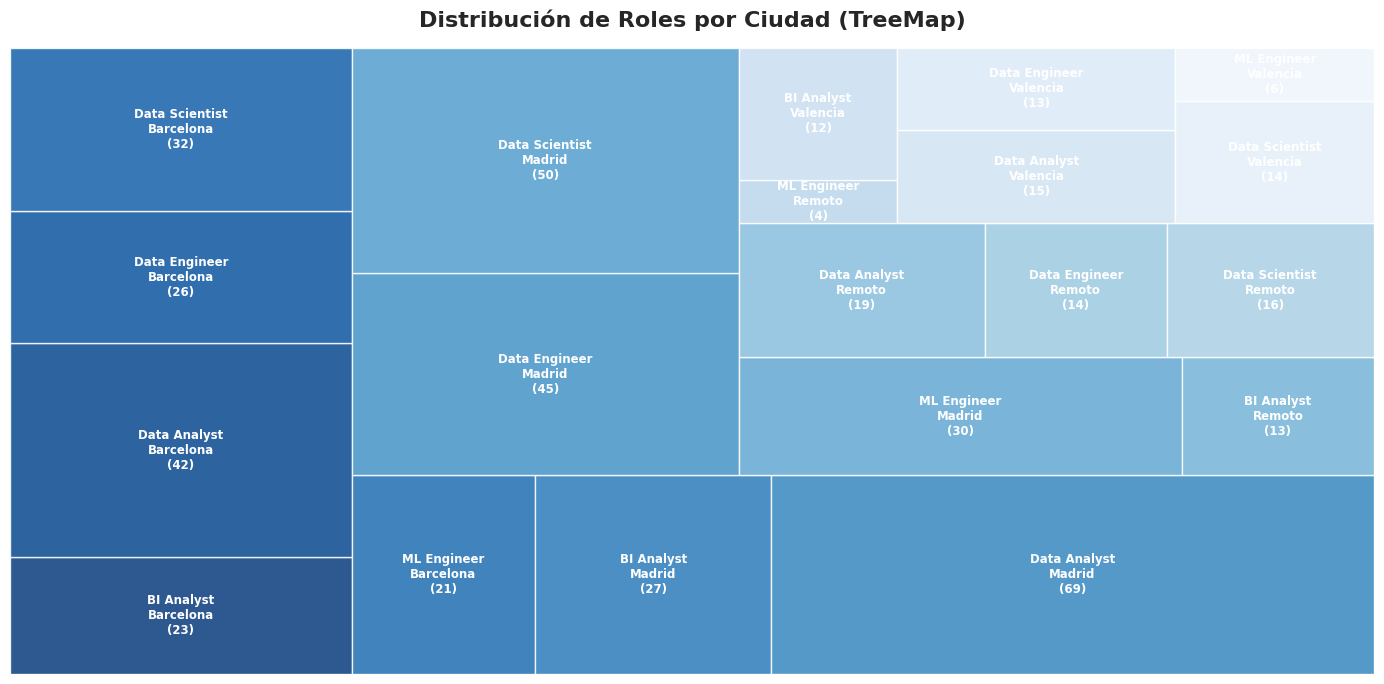

✅ TreeMap generado.


In [6]:
# ── G Extra: TreeMap de Roles por Ciudad ──
if city_col and 'job_title' in df.columns:
    pivot = df.groupby([city_col, 'job_title']).size().reset_index(name='count')
    top_cities = df[city_col].value_counts().head(4).index
    pivot_top = pivot[pivot[city_col].isin(top_cities)]

    fig, ax = plt.subplots(figsize=(14, 7))
    squarify.plot(sizes=pivot_top['count'],
                  label=[f"{r['job_title']}\n{r[city_col]}\n({r['count']})"
                         for _, r in pivot_top.iterrows()],
                  color=sns.color_palette('Blues_r', len(pivot_top)),
                  alpha=0.85, text_kwargs={'fontsize': 8.5, 'color': 'white',
                                           'fontweight': 'bold'}, ax=ax)
    ax.set_title('Distribución de Roles por Ciudad (TreeMap)', fontsize=16, fontweight='bold', pad=15)
    ax.axis('off')
    plt.tight_layout()
    plt.savefig('images/01b_treemap_roles_ciudad.png', dpi=200, bbox_inches='tight')
    plt.show()
    print("✅ TreeMap generado.")

## 💶 Bloque 2 — Análisis Retributivo y Salarial

Distribuciones salariales cruzadas con seniority, modalidad, ciudad y rol.  
Se incluyen tests estadísticos para validar diferencias entre grupos.


💶 Registros con salario válido (sin outliers): 597
   Mediana: 35,496 € | Media: 39,332 €
   P10: 30,000 € | P90: 52,000 €


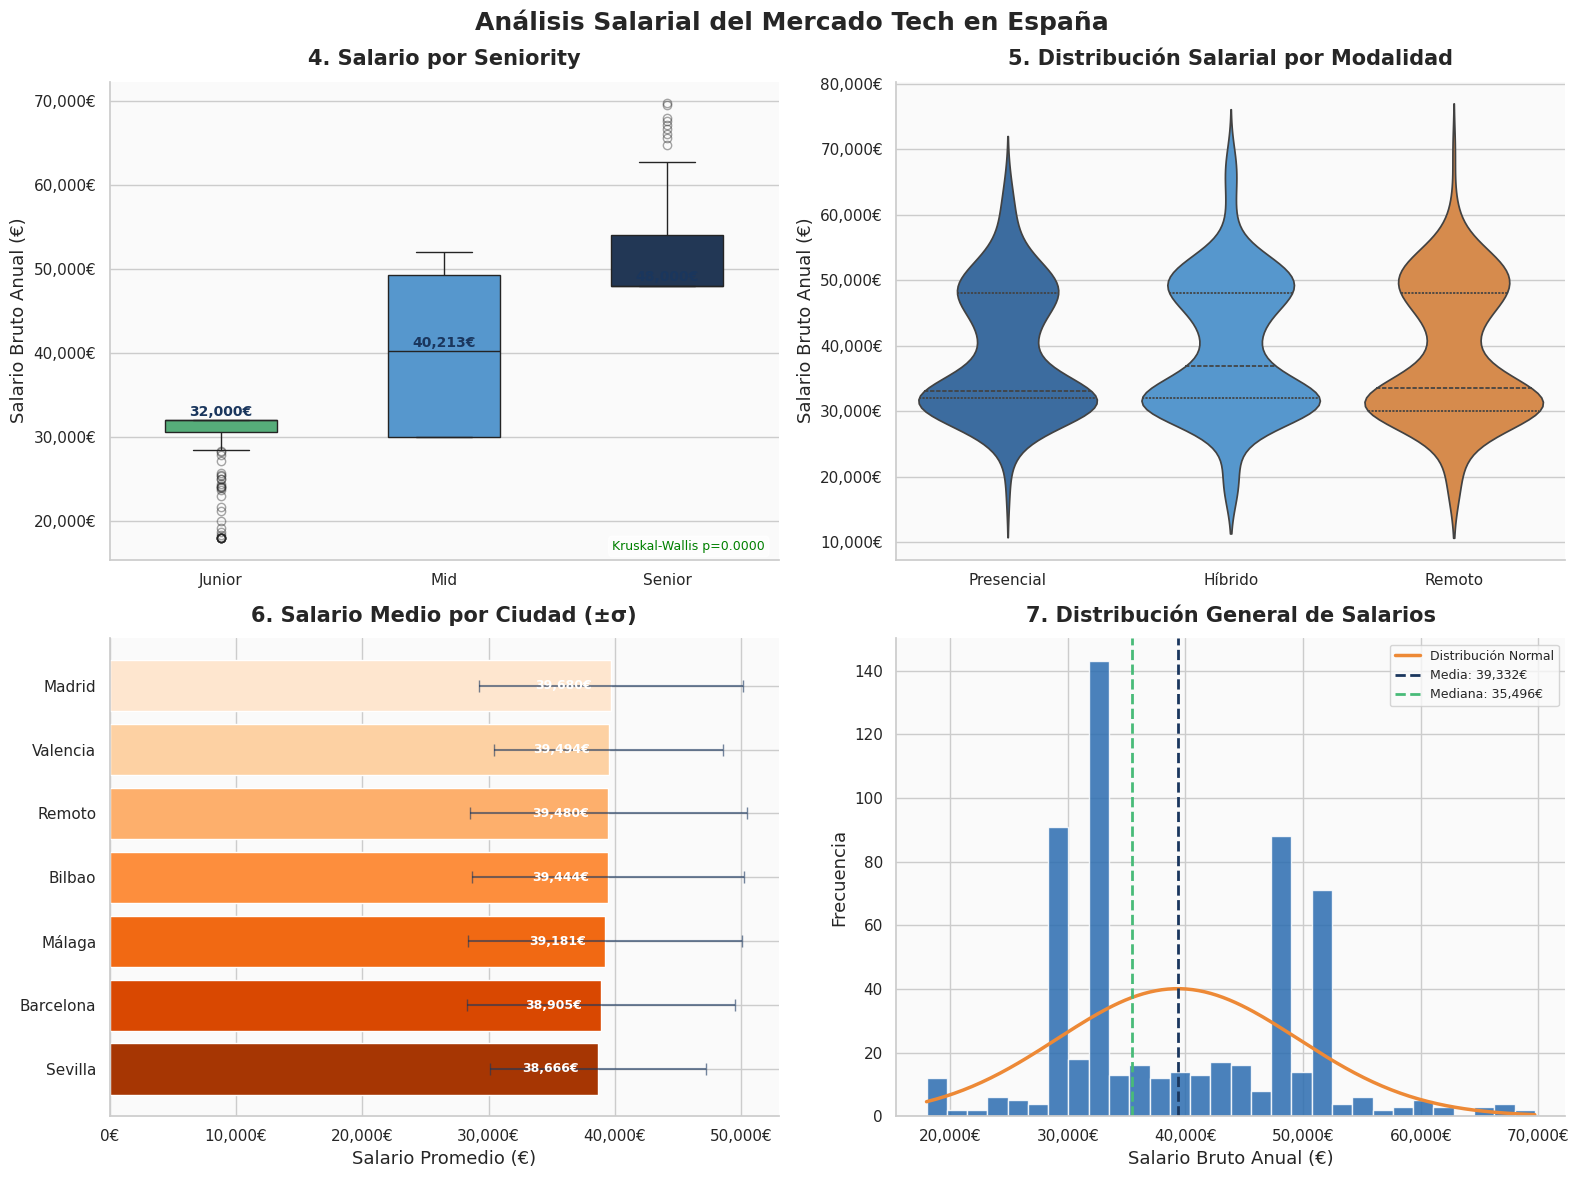

✅ Gráficos 4-7 generados.


In [7]:
# ============================================================
# BLOQUE 2: ANÁLISIS SALARIAL (Gráficos 4-7)
# ============================================================

sal_col = 'salary_clean' if 'salary_clean' in df.columns else 'salary'
df_sal = df[df[sal_col].notna() & ~df.get('salary_clean_outlier', pd.Series([False]*len(df)))].copy()

print(f"💶 Registros con salario válido (sin outliers): {len(df_sal):,}")
print(f"   Mediana: {df_sal[sal_col].median():,.0f} € | Media: {df_sal[sal_col].mean():,.0f} €")
print(f"   P10: {df_sal[sal_col].quantile(0.1):,.0f} € | P90: {df_sal[sal_col].quantile(0.9):,.0f} €")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Análisis Salarial del Mercado Tech en España', fontsize=18, fontweight='bold')

# G4: Boxplot seniority
if 'seniority' in df_sal.columns:
    order = ['Junior','Mid','Senior']
    sns.boxplot(x='seniority', y=sal_col, data=df_sal, order=order,
                palette=['#48BB78','#4299E1','#1A365D'],
                width=0.5, flierprops=dict(marker='o', alpha=0.4), ax=axes[0,0])
    medians = df_sal.groupby('seniority')[sal_col].median()
    for i, s in enumerate(order):
        if s in medians:
            axes[0,0].text(i, medians[s] + 500, f'{medians[s]:,.0f}€',
                           ha='center', fontweight='bold', fontsize=10,
                           color=PALETA['primary'])
    axes[0,0].set_title('4. Salario por Seniority', pad=12)
    axes[0,0].set_xlabel('')
    axes[0,0].set_ylabel('Salario Bruto Anual (€)')
    axes[0,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}€'))

    # Test Kruskal-Wallis
    groups = [df_sal[df_sal['seniority']==s][sal_col].dropna() for s in order if s in df_sal['seniority'].values]
    if len(groups) == 3:
        stat, pval = kruskal(*groups)
        axes[0,0].text(0.98, 0.02, f'Kruskal-Wallis p={pval:.4f}',
                       transform=axes[0,0].transAxes, ha='right', fontsize=9,
                       color='green' if pval < 0.05 else 'red',
                       bbox=dict(boxstyle='round', fc='white', alpha=0.8))

# G5: Violin modalidad
if 'remote_modality' in df_sal.columns:
    order_m = ['Presencial','Híbrido','Remoto']
    avail_m  = [m for m in order_m if m in df_sal['remote_modality'].values]
    sns.violinplot(x='remote_modality', y=sal_col, data=df_sal, order=avail_m,
                   palette=[PALETA['secondary'], PALETA['accent'], PALETA['warm']],
                   inner='quartile', ax=axes[0,1])
    axes[0,1].set_title('5. Distribución Salarial por Modalidad', pad=12)
    axes[0,1].set_xlabel('')
    axes[0,1].set_ylabel('Salario Bruto Anual (€)')
    axes[0,1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}€'))

# G6: Salario medio por ciudad
if city_col:
    sal_ciu = df_sal.groupby(city_col)[sal_col].agg(['mean','std','count']).reset_index()
    sal_ciu = sal_ciu[sal_ciu['count'] >= 5].sort_values('mean', ascending=True)
    bars = axes[1,0].barh(sal_ciu[city_col], sal_ciu['mean'],
                          xerr=sal_ciu['std'], capsize=4,
                          color=sns.color_palette('Oranges_r', len(sal_ciu)),
                          error_kw=dict(ecolor=PALETA['primary'], alpha=0.6))
    axes[1,0].set_title('6. Salario Medio por Ciudad (±σ)', pad=12)
    axes[1,0].set_xlabel('Salario Promedio (€)')
    axes[1,0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}€'))
    for bar, row in zip(bars, sal_ciu.itertuples()):
        axes[1,0].text(row.mean - 1500, bar.get_y() + bar.get_height()/2,
                       f'{row.mean:,.0f}€', va='center', ha='right',
                       fontweight='bold', fontsize=9, color='white')

# G7: Histograma distribución salarial total
axes[1,1].hist(df_sal[sal_col].dropna(), bins=30,
               color=PALETA['secondary'], edgecolor='white', alpha=0.85)
mu, sigma = df_sal[sal_col].mean(), df_sal[sal_col].std()
x = np.linspace(df_sal[sal_col].min(), df_sal[sal_col].max(), 200)
axes[1,1].plot(x, stats.norm.pdf(x, mu, sigma) * len(df_sal[sal_col].dropna()) * (df_sal[sal_col].max() - df_sal[sal_col].min()) / 30,
               color=PALETA['warm'], linewidth=2.5, label='Distribución Normal')
axes[1,1].axvline(mu, color=PALETA['primary'], linestyle='--', linewidth=2, label=f'Media: {mu:,.0f}€')
axes[1,1].axvline(df_sal[sal_col].median(), color=PALETA['success'],
                   linestyle='--', linewidth=2, label=f'Mediana: {df_sal[sal_col].median():,.0f}€')
axes[1,1].set_title('7. Distribución General de Salarios', pad=12)
axes[1,1].set_xlabel('Salario Bruto Anual (€)')
axes[1,1].set_ylabel('Frecuencia')
axes[1,1].legend(fontsize=9)
axes[1,1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}€'))

plt.tight_layout()
plt.savefig('images/02_analisis_salarial.png', dpi=200, bbox_inches='tight')
plt.show()
print("✅ Gráficos 4-7 generados.")

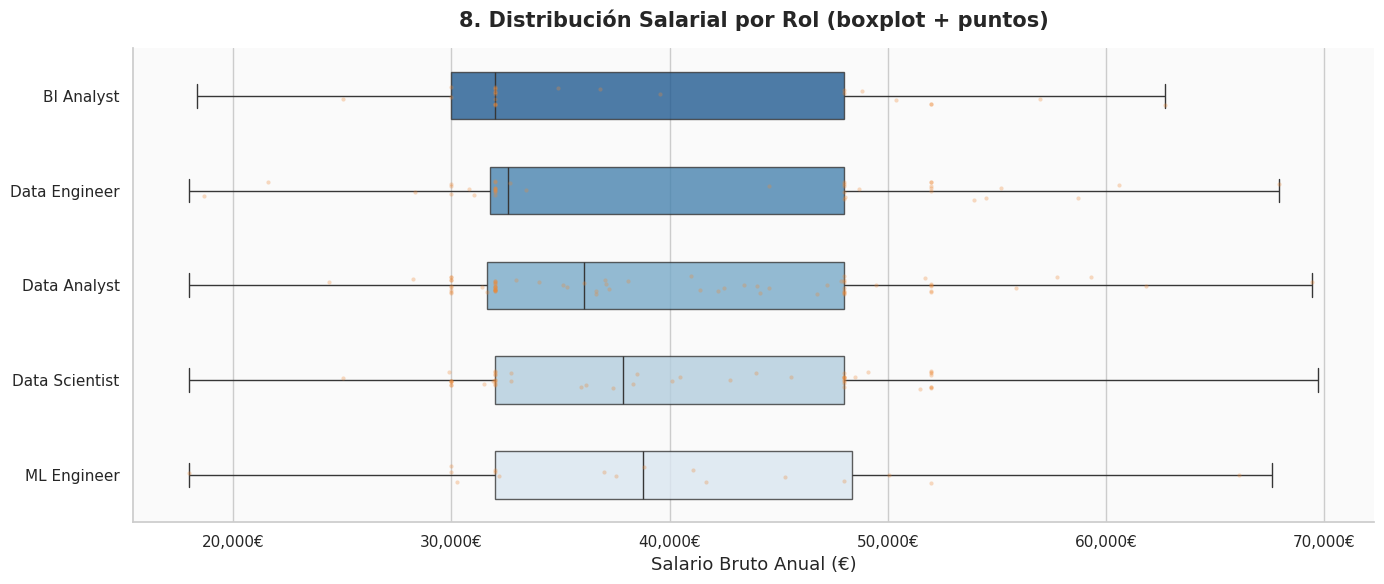

✅ Gráfico 8 generado.


In [8]:
# ── G8: Salario por Rol con scatter strip ──
if 'job_title' in df_sal.columns:
    fig, ax = plt.subplots(figsize=(14, 6))
    order_roles = df_sal.groupby('job_title')[sal_col].median().sort_values().index

    sns.boxplot(x=sal_col, y='job_title', data=df_sal, order=order_roles,
                palette='Blues_r', width=0.5, fliersize=0,
                boxprops=dict(alpha=0.8), ax=ax)
    sns.stripplot(x=sal_col, y='job_title', data=df_sal.sample(min(200, len(df_sal))),
                  order=order_roles, color=PALETA['warm'], alpha=0.3,
                  jitter=True, size=3, ax=ax)

    ax.set_title('8. Distribución Salarial por Rol (boxplot + puntos)', fontsize=15, fontweight='bold', pad=15)
    ax.set_xlabel('Salario Bruto Anual (€)')
    ax.set_ylabel('')
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}€'))

    plt.tight_layout()
    plt.savefig('images/02b_salario_rol.png', dpi=200, bbox_inches='tight')
    plt.show()
    print("✅ Gráfico 8 generado.")

## 🔥 Bloque 3 — Mapas de Calor y Análisis de Correlaciones

Los mapas de calor permiten identificar relaciones entre variables categóricas y numéricas de forma visual e intuitiva.


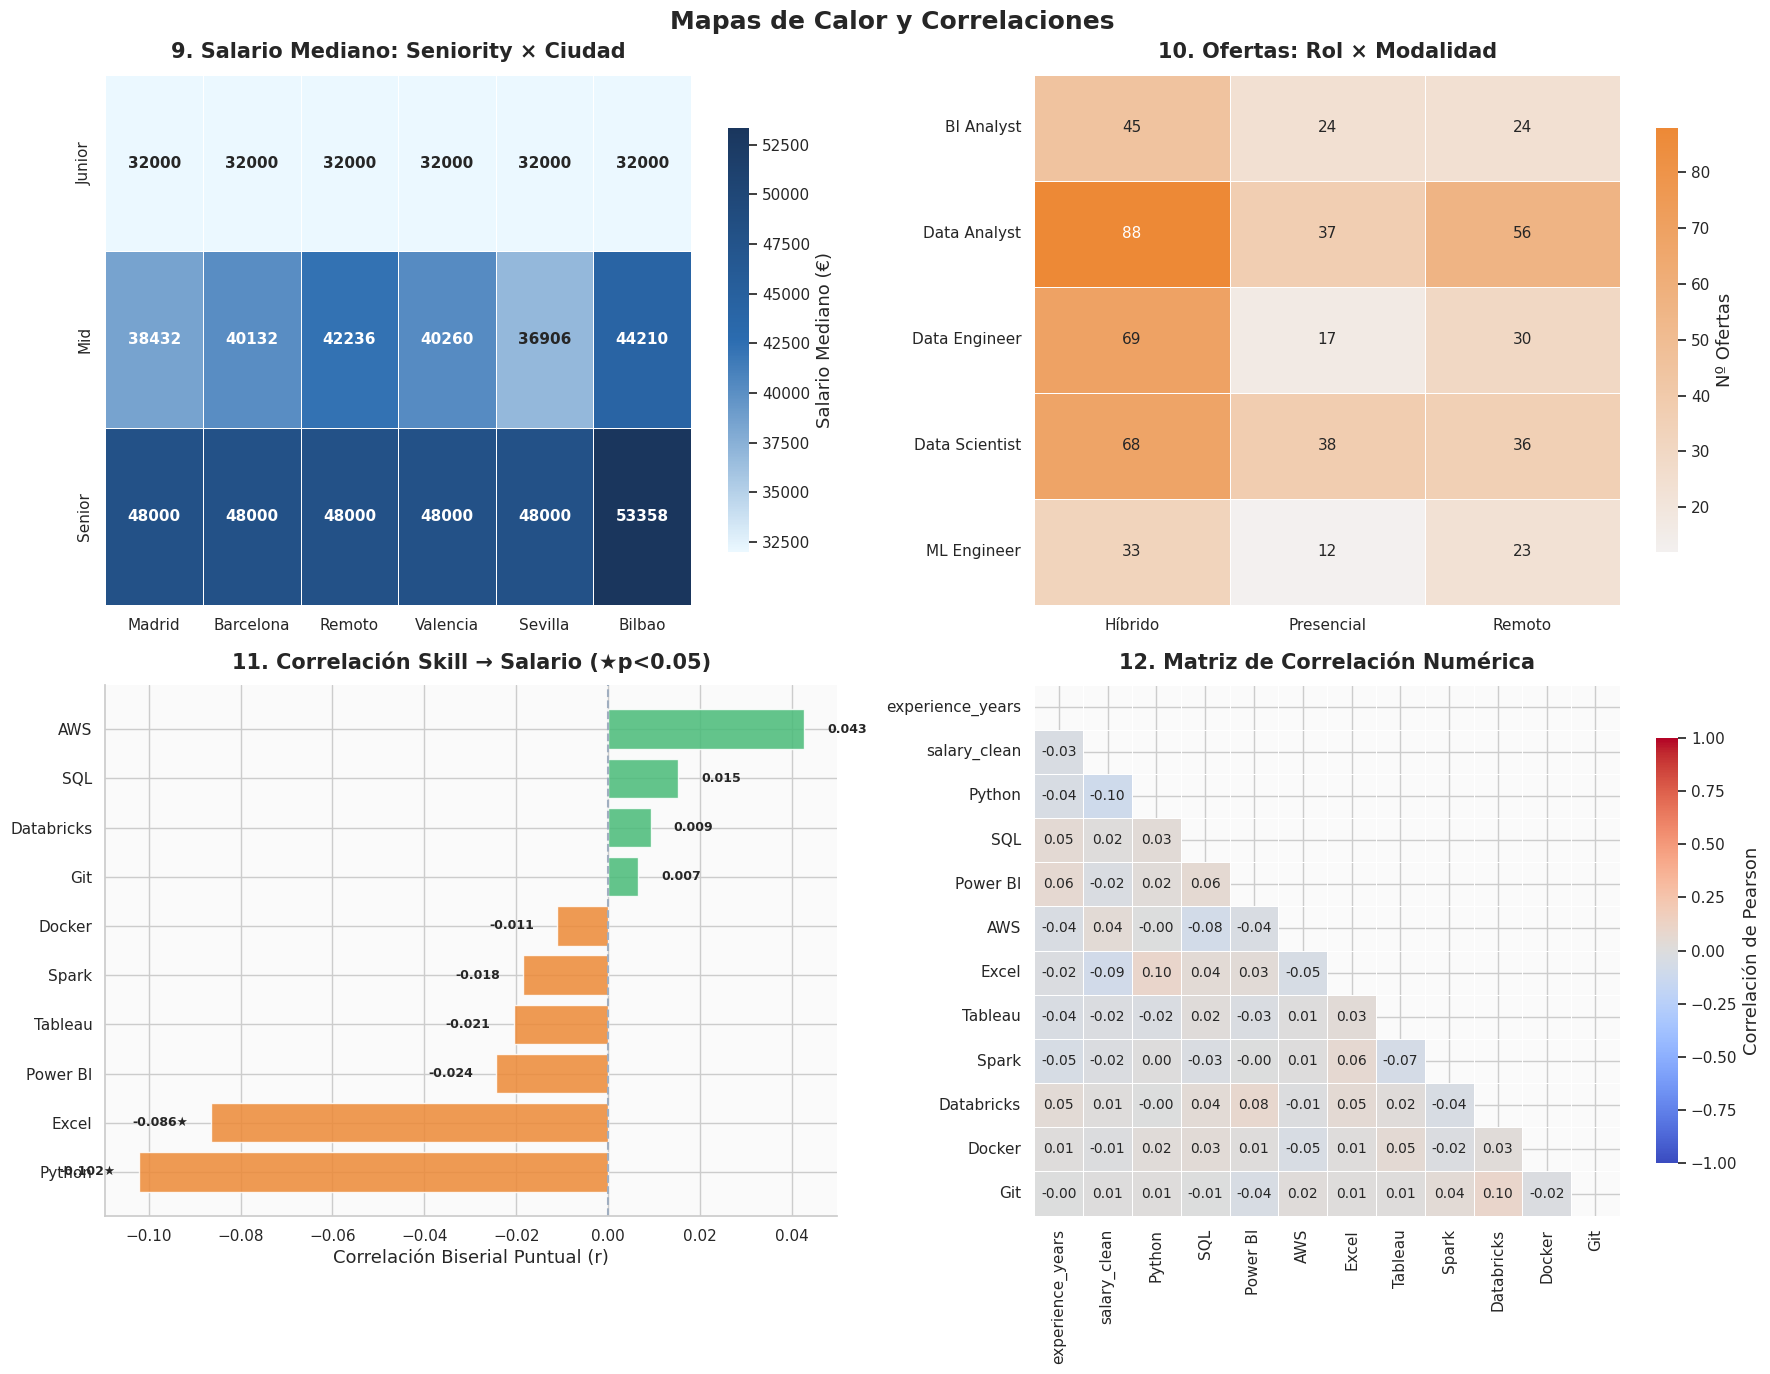

✅ Heatmaps 9-12 generados.


In [9]:
# ============================================================
# BLOQUE 3: HEATMAPS (Gráficos 9-12)
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Mapas de Calor y Correlaciones', fontsize=18, fontweight='bold')

# G9: Heatmap Seniority × Ciudad → Salario Medio
if 'seniority' in df_sal.columns and city_col:
    pivot_sal = df_sal.pivot_table(values=sal_col, index='seniority',
                                   columns=city_col, aggfunc='median')
    pivot_sal = pivot_sal.reindex(['Junior','Mid','Senior'])
    top_cities_h = df_sal[city_col].value_counts().head(6).index
    pivot_sal = pivot_sal[top_cities_h]

    custom_cmap = LinearSegmentedColormap.from_list('dt', [PALETA['light'], PALETA['secondary'], PALETA['primary']])
    sns.heatmap(pivot_sal, annot=True, fmt='.0f', cmap=custom_cmap,
                linewidths=0.5, linecolor='white', ax=axes[0,0],
                annot_kws={'fontsize': 11, 'fontweight': 'bold'},
                cbar_kws={'label': 'Salario Mediano (€)', 'shrink': 0.8})
    axes[0,0].set_title('9. Salario Mediano: Seniority × Ciudad', pad=12)
    axes[0,0].set_xlabel('')
    axes[0,0].set_ylabel('')

# G10: Heatmap Rol × Modalidad → Número de Ofertas
if 'job_title' in df.columns and 'remote_modality' in df.columns:
    pivot_count = df.pivot_table(values=sal_col if sal_col in df.columns else 'job_title',
                                 index='job_title', columns='remote_modality',
                                 aggfunc='count')
    sns.heatmap(pivot_count, annot=True, fmt='.0f',
                cmap=sns.light_palette(PALETA['warm'], as_cmap=True),
                linewidths=0.5, linecolor='white', ax=axes[0,1],
                annot_kws={'fontsize': 11},
                cbar_kws={'label': 'Nº Ofertas', 'shrink': 0.8})
    axes[0,1].set_title('10. Ofertas: Rol × Modalidad', pad=12)
    axes[0,1].set_xlabel('')
    axes[0,1].set_ylabel('')

# G11: Correlación entre skills y salario
if len(SKILLS_COLS) >= 3:
    skill_corrs = {}
    for s in SKILLS_COLS:
        sub = df_sal[[s, sal_col]].dropna()
        sub = sub[sub[s].isin([0,1])]
        if len(sub) > 10:
            r, p = stats.pointbiserialr(sub[s], sub[sal_col])
            skill_corrs[s] = {'r': r, 'p': p}
    if skill_corrs:
        sc_df = pd.DataFrame(skill_corrs).T.sort_values('r', ascending=True)
        colors_corr = [PALETA['success'] if v > 0 else PALETA['warm'] for v in sc_df['r']]
        bars_c = axes[1,0].barh(sc_df.index, sc_df['r'], color=colors_corr, alpha=0.85)
        axes[1,0].axvline(0, color=PALETA['muted'], linewidth=1.5, linestyle='--')
        for bar, (idx, row) in zip(bars_c, sc_df.iterrows()):
            sig = '★' if row['p'] < 0.05 else ''
            axes[1,0].text(row['r'] + 0.005 if row['r'] > 0 else row['r'] - 0.005,
                           bar.get_y() + bar.get_height()/2,
                           f"{row['r']:.3f}{sig}", va='center',
                           ha='left' if row['r'] > 0 else 'right',
                           fontsize=9, fontweight='bold')
        axes[1,0].set_title('11. Correlación Skill → Salario (★p<0.05)', pad=12)
        axes[1,0].set_xlabel('Correlación Biserial Puntual (r)')

# G12: Heatmap Correlación numérica general
num_cols = df_sal.select_dtypes(include=[np.number]).drop(
    columns=['salary_clean_outlier'] if 'salary_clean_outlier' in df_sal.columns else [], errors='ignore'
).columns.tolist()
if len(num_cols) >= 3:
    corr_matrix = df_sal[num_cols].corr()
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
                cmap='coolwarm', center=0, vmin=-1, vmax=1,
                linewidths=0.5, linecolor='white', ax=axes[1,1],
                annot_kws={'fontsize': 10},
                cbar_kws={'label': 'Correlación de Pearson', 'shrink': 0.8})
    axes[1,1].set_title('12. Matriz de Correlación Numérica', pad=12)

plt.tight_layout()
plt.savefig('images/03_heatmaps_correlaciones.png', dpi=200, bbox_inches='tight')
plt.show()
print("✅ Heatmaps 9-12 generados.")

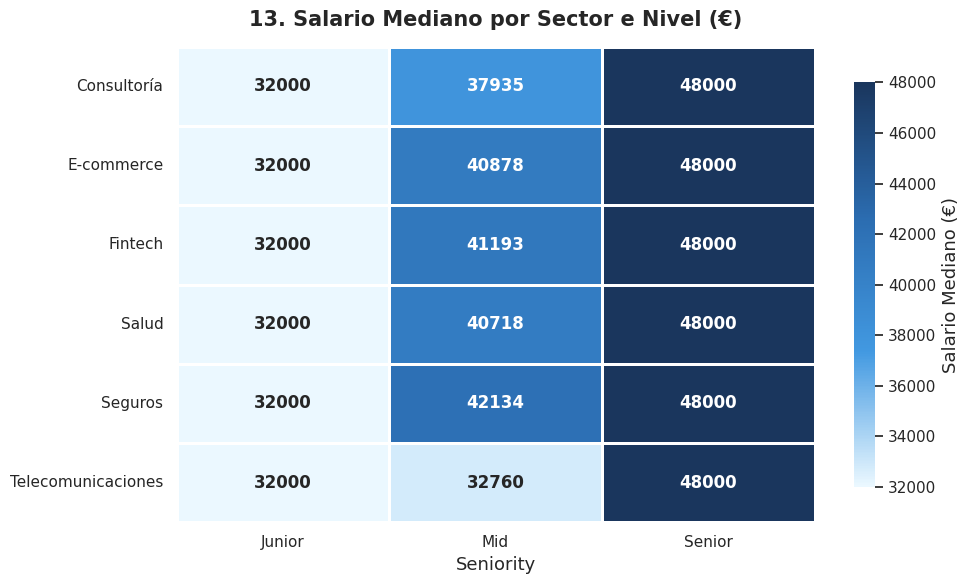

✅ Heatmap sector×seniority generado.


In [10]:
# ── G13: Heatmap Sector × Seniority → Salario ──
if 'sector' in df_sal.columns and 'seniority' in df_sal.columns:
    pivot_sec = df_sal.pivot_table(values=sal_col, index='sector',
                                   columns='seniority', aggfunc='median')
    pivot_sec = pivot_sec.reindex(columns=['Junior','Mid','Senior'])

    fig, ax = plt.subplots(figsize=(10, 6))
    custom_cmap2 = LinearSegmentedColormap.from_list('dt2',
        ['#EBF8FF', PALETA['accent'], PALETA['secondary'], PALETA['primary']])
    sns.heatmap(pivot_sec, annot=True, fmt='.0f', cmap=custom_cmap2,
                linewidths=0.8, linecolor='white', ax=ax,
                annot_kws={'fontsize': 12, 'fontweight': 'bold'},
                cbar_kws={'label': 'Salario Mediano (€)', 'shrink': 0.85})
    ax.set_title('13. Salario Mediano por Sector e Nivel (€)', fontsize=15, fontweight='bold', pad=15)
    ax.set_xlabel('Seniority')
    ax.set_ylabel('')
    plt.tight_layout()
    plt.savefig('images/03b_heatmap_sector_seniority.png', dpi=200, bbox_inches='tight')
    plt.show()
    print("✅ Heatmap sector×seniority generado.")

## 🚀 Bloque 4 — Stack Tecnológico y Brecha Used vs Wanted

Análisis de los lenguajes y herramientas más demandados, comparando el uso real con la intención de aprendizaje de la encuesta Stack Overflow.


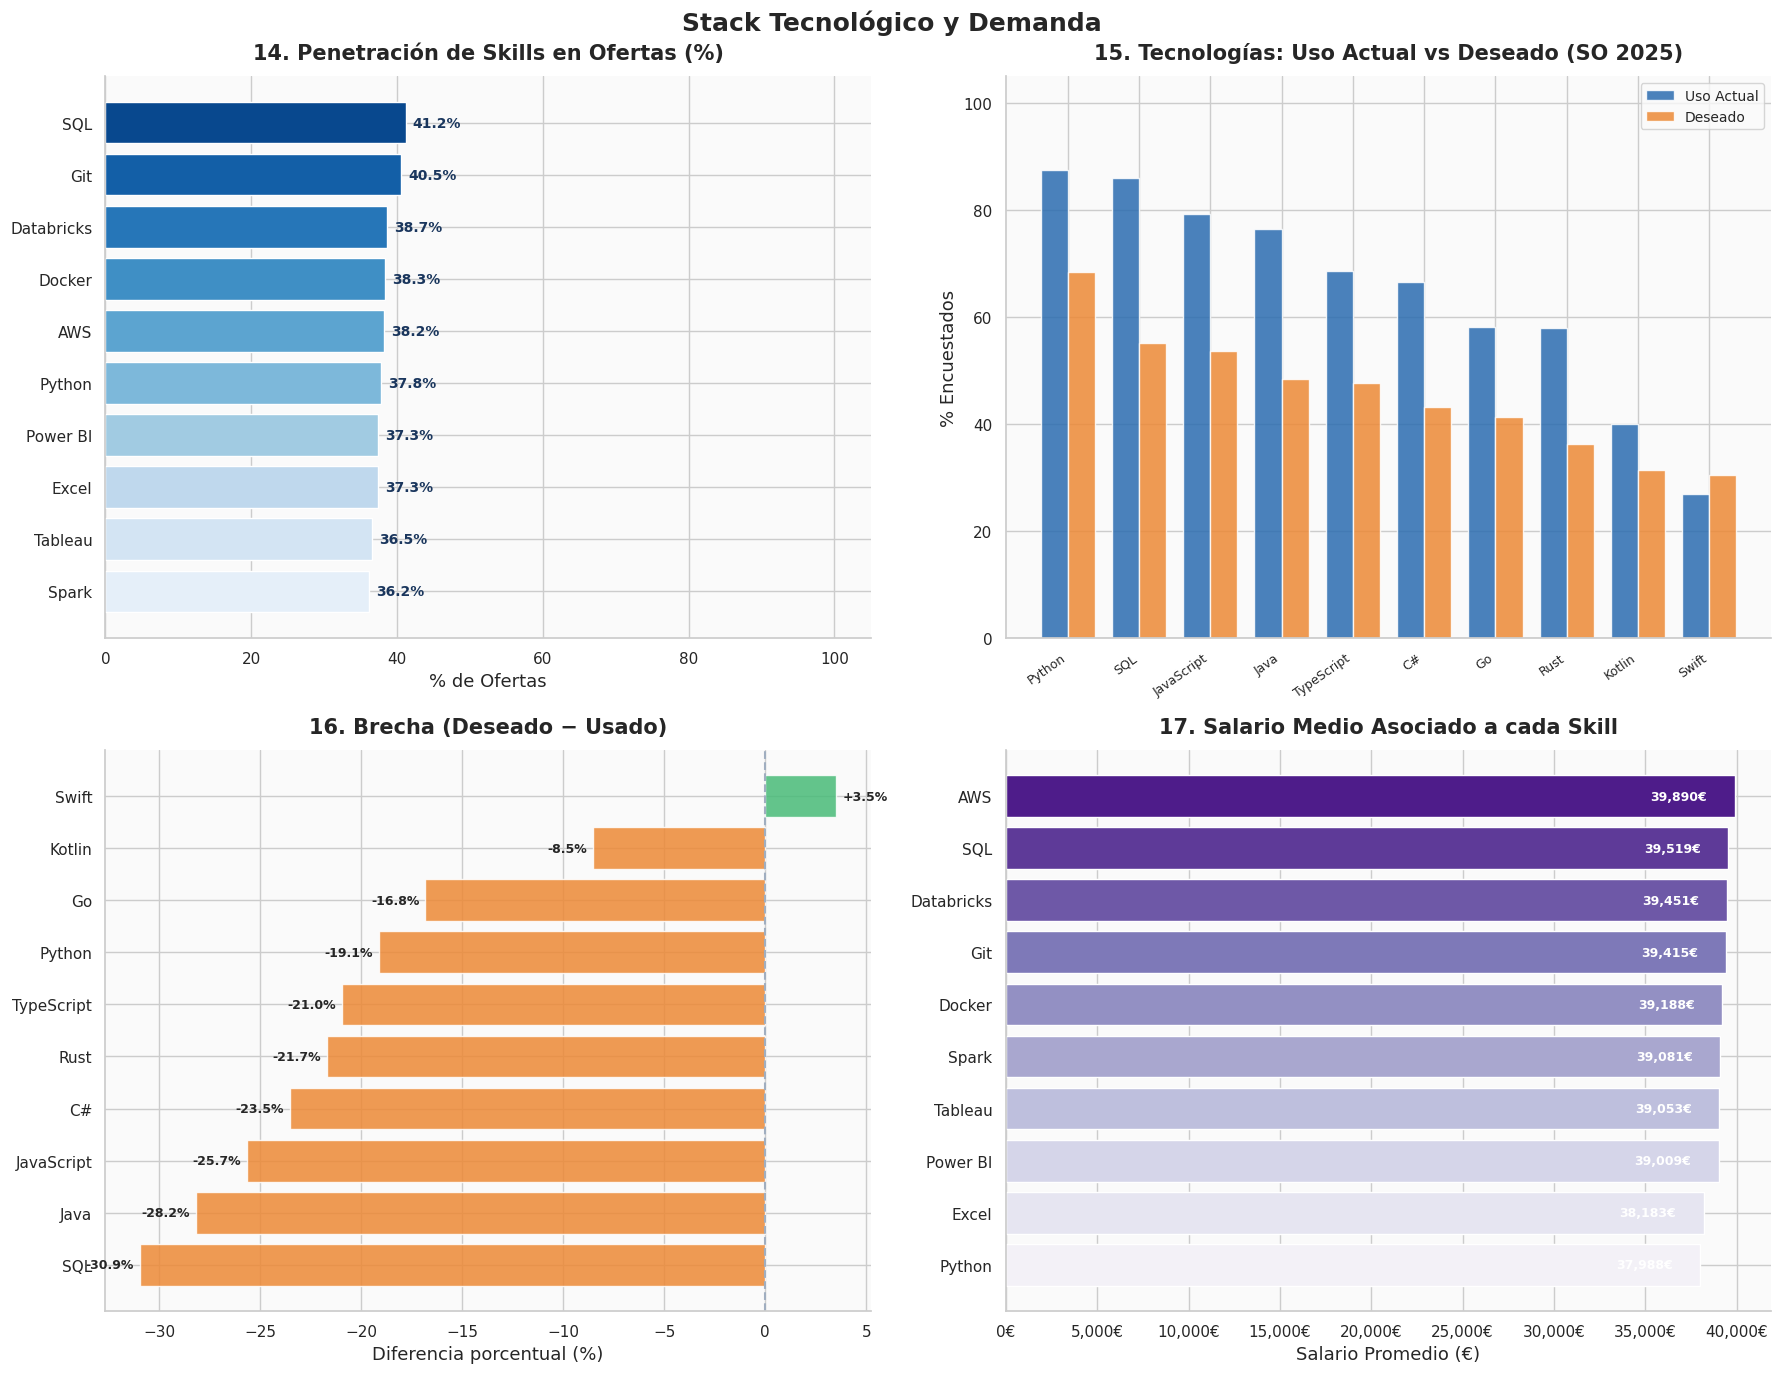

✅ Gráficos 14-17 generados.


In [11]:
# ============================================================
# BLOQUE 4: STACK TECNOLÓGICO (Gráficos 14-17)
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Stack Tecnológico y Demanda', fontsize=18, fontweight='bold')

# G14: Top skills en ofertas
if SKILLS_COLS:
    pct_skills = (df[SKILLS_COLS].sum() / len(df) * 100).sort_values(ascending=False)
    colors_sk = sns.color_palette('Blues_r', len(pct_skills))
    bars_sk = axes[0,0].barh(pct_skills.index, pct_skills.values,
                              color=colors_sk, edgecolor='white')
    axes[0,0].set_title('14. Penetración de Skills en Ofertas (%)', pad=12)
    axes[0,0].set_xlabel('% de Ofertas')
    axes[0,0].set_xlim(0, 105)
    for bar, val in zip(bars_sk, pct_skills.values):
        axes[0,0].text(val + 1, bar.get_y() + bar.get_height()/2,
                       f'{val:.1f}%', va='center', fontsize=10, fontweight='bold',
                       color=PALETA['primary'])
    axes[0,0].invert_yaxis()

# G15: Used vs Wanted (Stack Overflow)
if TECH_REAL:
    col_tech = 'technology' if 'technology' in df_used.columns else df_used.columns[0]
    col_pct  = 'pct'        if 'pct'        in df_used.columns else df_used.columns[1]
    top_u = df_used.nlargest(10, col_pct)
    top_w = df_wanted.nlargest(10, col_pct)
else:
    top_u = df_used.head(10)
    top_w = df_wanted.head(10)
    col_tech, col_pct = 'technology', 'pct'

# Merge para comparativa
merged_tech = top_u[[col_tech, col_pct]].rename(columns={col_pct: 'Usado'}).merge(
    top_w[[col_tech, col_pct]].rename(columns={col_pct: 'Deseado'}),
    on=col_tech, how='outer'
).fillna(0).sort_values('Usado', ascending=False)

x_pos = np.arange(len(merged_tech))
width = 0.38
b1 = axes[0,1].bar(x_pos - width/2, merged_tech['Usado'],   width=width, label='Uso Actual',
                    color=PALETA['secondary'], alpha=0.85, edgecolor='white')
b2 = axes[0,1].bar(x_pos + width/2, merged_tech['Deseado'], width=width, label='Deseado',
                    color=PALETA['warm'],      alpha=0.85, edgecolor='white')
axes[0,1].set_xticks(x_pos)
axes[0,1].set_xticklabels(merged_tech[col_tech], rotation=35, ha='right', fontsize=9)
axes[0,1].set_title('15. Tecnologías: Uso Actual vs Deseado (SO 2025)', pad=12)
axes[0,1].set_ylabel('% Encuestados')
axes[0,1].legend(fontsize=10)
axes[0,1].set_ylim(0, merged_tech[['Usado','Deseado']].max().max() * 1.2)

# G16: Brecha (gap) Wanted - Used
merged_tech['Gap'] = merged_tech['Deseado'] - merged_tech['Usado']
merged_sorted = merged_tech.sort_values('Gap', ascending=True)
colors_gap = [PALETA['success'] if g > 0 else PALETA['warm'] for g in merged_sorted['Gap']]
bars_gap = axes[1,0].barh(merged_sorted[col_tech], merged_sorted['Gap'],
                           color=colors_gap, edgecolor='white', alpha=0.85)
axes[1,0].axvline(0, color=PALETA['muted'], linewidth=1.5, linestyle='--')
axes[1,0].set_title('16. Brecha (Deseado − Usado)', pad=12)
axes[1,0].set_xlabel('Diferencia porcentual (%)')
for bar, val in zip(bars_gap, merged_sorted['Gap']):
    axes[1,0].text(val + 0.3 if val >= 0 else val - 0.3,
                   bar.get_y() + bar.get_height()/2,
                   f'{val:+.1f}%', va='center',
                   ha='left' if val >= 0 else 'right',
                   fontsize=9, fontweight='bold')

# G17: Salario por skill (si skills disponibles)
if len(SKILLS_COLS) >= 3:
    sal_skill = {s: df_sal[df_sal[s]==1][sal_col].mean()
                 for s in SKILLS_COLS if s in df_sal.columns}
    sal_skill = {k: v for k, v in sal_skill.items() if not np.isnan(v)}
    sal_skill_s = sorted(sal_skill.items(), key=lambda x: x[1], reverse=True)
    names, vals = zip(*sal_skill_s)
    colors_ss = sns.color_palette('Purples_r', len(names))
    bars_ss = axes[1,1].barh(names, vals, color=colors_ss, edgecolor='white')
    axes[1,1].set_title('17. Salario Medio Asociado a cada Skill', pad=12)
    axes[1,1].set_xlabel('Salario Promedio (€)')
    axes[1,1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}€'))
    axes[1,1].invert_yaxis()
    for bar, val in zip(bars_ss, vals):
        axes[1,1].text(val - 1500, bar.get_y() + bar.get_height()/2,
                       f'{val:,.0f}€', va='center', ha='right',
                       fontweight='bold', fontsize=9, color='white')

plt.tight_layout()
plt.savefig('images/04_tecnologias.png', dpi=200, bbox_inches='tight')
plt.show()
print("✅ Gráficos 14-17 generados.")

## 📐 Bloque 5 — Análisis Estadístico Avanzado

Regresión salarial, Q-Q plots, pruebas de normalidad y análisis de varianza no paramétrico.


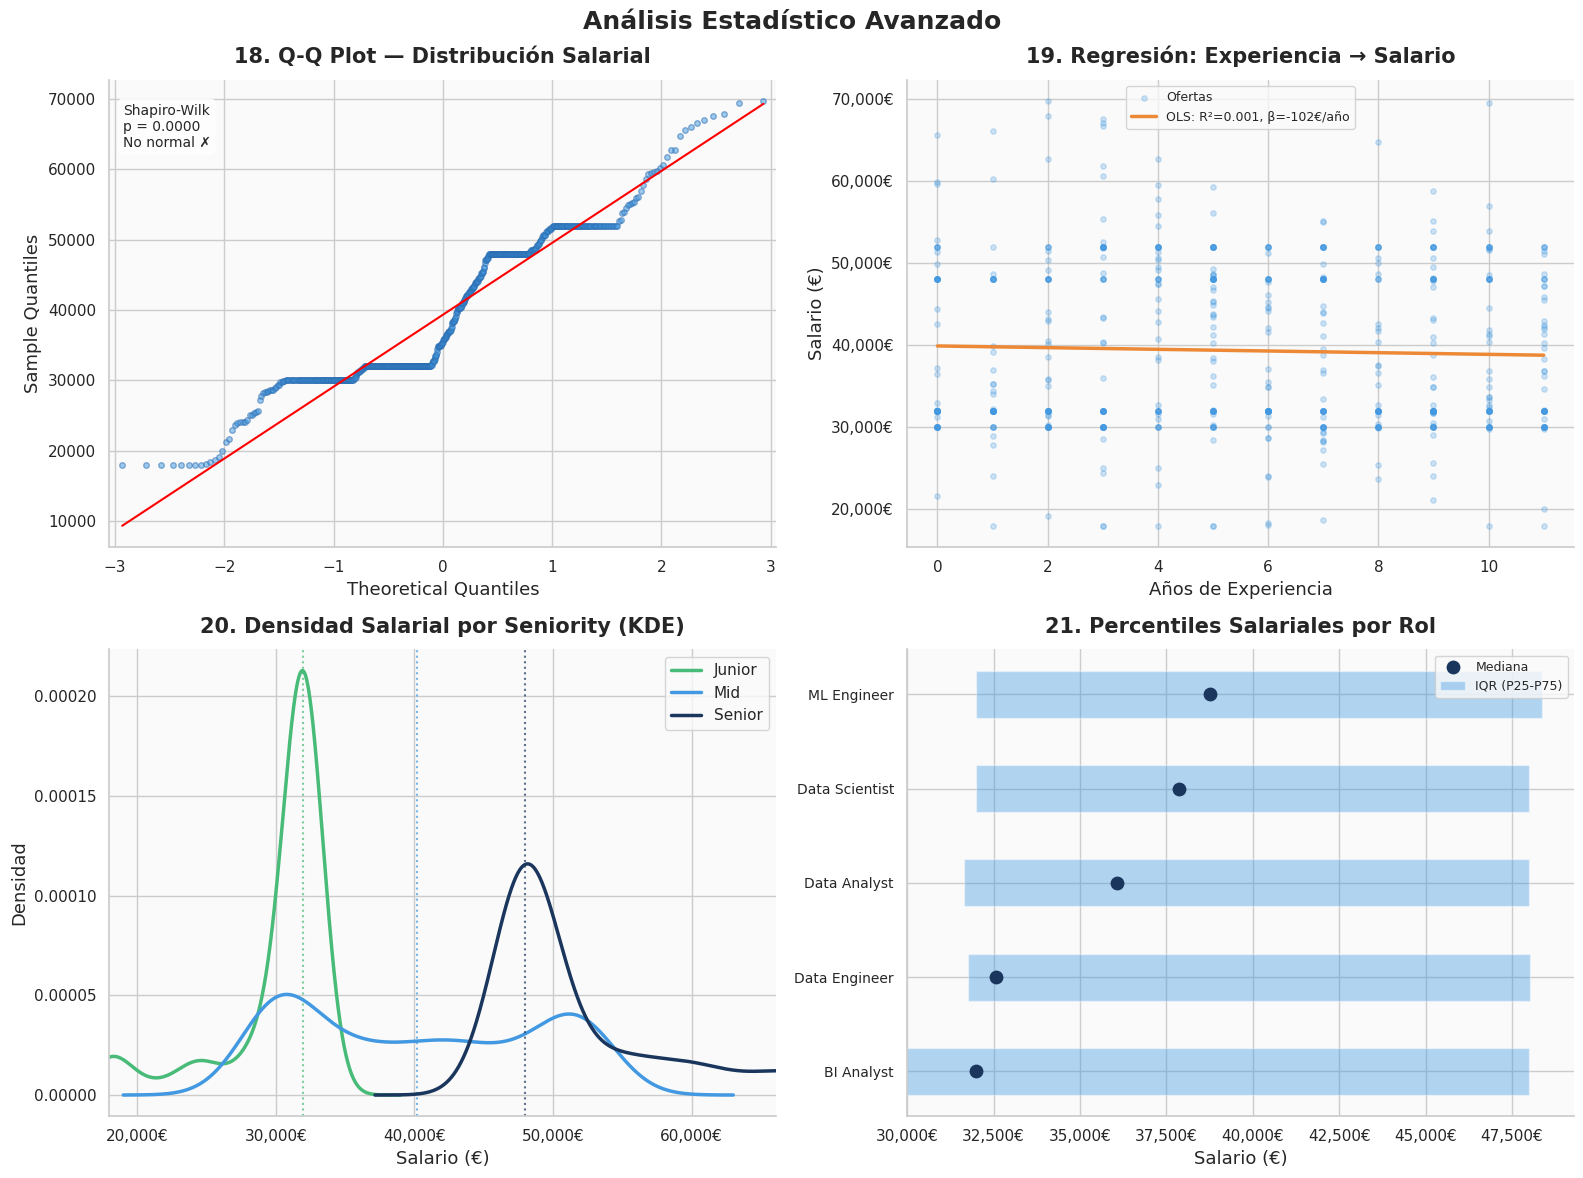

✅ Gráficos estadísticos 18-21 generados.


In [12]:
# ============================================================
# BLOQUE 5: ESTADÍSTICA AVANZADA (Gráficos 18-21)
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Análisis Estadístico Avanzado', fontsize=18, fontweight='bold')

# G18: Q-Q Plot de salarios
if sal_col in df_sal.columns and len(df_sal[sal_col].dropna()) > 20:
    sm.qqplot(df_sal[sal_col].dropna(), line='s', ax=axes[0,0],
              markerfacecolor=PALETA['accent'], markeredgecolor=PALETA['secondary'],
              alpha=0.5, markersize=4)
    axes[0,0].set_title('18. Q-Q Plot — Distribución Salarial', pad=12)
    # Test Shapiro en muestra
    sample = df_sal[sal_col].dropna().sample(min(200, len(df_sal)), random_state=42)
    stat_sw, p_sw = stats.shapiro(sample)
    axes[0,0].text(0.02, 0.95, f'Shapiro-Wilk\np = {p_sw:.4f}\n{"Normal ✓" if p_sw>0.05 else "No normal ✗"}',
                   transform=axes[0,0].transAxes, va='top', fontsize=10,
                   bbox=dict(boxstyle='round', fc='white', alpha=0.8))

# G19: Regresión Exp. × Salario
if 'experience_years' in df_sal.columns:
    x = df_sal['experience_years'].dropna()
    y = df_sal.loc[x.index, sal_col].dropna()
    common = x.index.intersection(y.index)
    x, y = x.loc[common], y.loc[common]

    axes[0,1].scatter(x, y, alpha=0.25, color=PALETA['accent'], s=15, label='Ofertas')
    # Regresión OLS
    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()
    x_line = np.linspace(x.min(), x.max(), 100)
    y_pred = model.params[0] + model.params[1] * x_line
    axes[0,1].plot(x_line, y_pred, color=PALETA['warm'], linewidth=2.5,
                   label=f'OLS: R²={model.rsquared:.3f}, β={model.params[1]:+.0f}€/año')
    axes[0,1].set_title('19. Regresión: Experiencia → Salario', pad=12)
    axes[0,1].set_xlabel('Años de Experiencia')
    axes[0,1].set_ylabel('Salario (€)')
    axes[0,1].legend(fontsize=9)
    axes[0,1].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:,.0f}€'))

# G20: KDE por seniority
if 'seniority' in df_sal.columns:
    order_s = ['Junior','Mid','Senior']
    pal_s   = [PALETA['success'], PALETA['accent'], PALETA['primary']]
    for s, c in zip(order_s, pal_s):
        sub = df_sal[df_sal['seniority']==s][sal_col].dropna()
        if len(sub) > 5:
            sub.plot.kde(ax=axes[1,0], label=s, color=c, linewidth=2.5)
            axes[1,0].axvline(sub.median(), color=c, linestyle=':', alpha=0.7, linewidth=1.5)
    axes[1,0].set_title('20. Densidad Salarial por Seniority (KDE)', pad=12)
    axes[1,0].set_xlabel('Salario (€)')
    axes[1,0].set_ylabel('Densidad')
    axes[1,0].legend()
    axes[1,0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}€'))
    axes[1,0].set_xlim(df_sal[sal_col].quantile(0.01), df_sal[sal_col].quantile(0.99))

# G21: Percentiles salariales por rol
if 'job_title' in df_sal.columns:
    pcts = df_sal.groupby('job_title')[sal_col].describe()[['25%','50%','75%']]
    pcts.columns = ['P25','Mediana','P75']
    pcts = pcts.sort_values('Mediana', ascending=True)

    y_pos = np.arange(len(pcts))
    axes[1,1].barh(y_pos, pcts['P75'] - pcts['P25'],
                   left=pcts['P25'], height=0.5,
                   color=PALETA['accent'], alpha=0.4, label='IQR (P25-P75)')
    axes[1,1].scatter(pcts['Mediana'], y_pos, color=PALETA['primary'],
                       s=80, zorder=5, label='Mediana')
    axes[1,1].set_yticks(y_pos)
    axes[1,1].set_yticklabels(pcts.index, fontsize=10)
    axes[1,1].set_title('21. Percentiles Salariales por Rol', pad=12)
    axes[1,1].set_xlabel('Salario (€)')
    axes[1,1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}€'))
    axes[1,1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('images/05_estadistica_avanzada.png', dpi=200, bbox_inches='tight')
plt.show()
print("✅ Gráficos estadísticos 18-21 generados.")

## 🌐 Bloque 6 — Visualizaciones Interactivas (Plotly)

Gráficos dinámicos que permiten explorar los datos con zoom, filtros y tooltips.


In [13]:
# ============================================================
# BLOQUE 6: PLOTLY INTERACTIVO (Gráficos 22-25)
# ============================================================

plotly_template = 'plotly_white'

# G22: Box interactivo — salario por seniority + rol
if 'seniority' in df_sal.columns and 'job_title' in df_sal.columns:
    fig22 = px.box(
        df_sal[df_sal['seniority'].isin(['Junior','Mid','Senior'])],
        x='seniority', y=sal_col, color='job_title',
        category_orders={'seniority': ['Junior','Mid','Senior']},
        title='22. Distribución Salarial: Seniority × Rol (interactivo)',
        labels={sal_col: 'Salario Bruto Anual (€)', 'seniority': '', 'job_title': 'Rol'},
        template=plotly_template,
        color_discrete_sequence=px.colors.qualitative.Bold,
        points='outliers',
    )
    fig22.update_layout(font_family='Arial', title_font_size=16, height=500)
    fig22.show()

# G23: Scatter — Experiencia vs Salario (interactivo)
if 'experience_years' in df_sal.columns and 'seniority' in df_sal.columns:
    fig23 = px.scatter(
        df_sal.dropna(subset=[sal_col, 'experience_years']),
        x='experience_years', y=sal_col,
        color='seniority', size=sal_col,
        hover_data=['job_title', city_col] if city_col else ['job_title'],
        title='23. Experiencia vs Salario (interactivo)',
        labels={sal_col: 'Salario (€)', 'experience_years': 'Años de Experiencia'},
        template=plotly_template,
        trendline='ols',
        color_discrete_map={'Junior': '#48BB78', 'Mid': '#4299E1', 'Senior': '#1A365D'},
        opacity=0.65,
    )
    fig23.update_layout(font_family='Arial', title_font_size=16, height=500)
    fig23.show()

# G24: Sunburst — Ciudad > Modalidad > Rol
if city_col and 'remote_modality' in df.columns and 'job_title' in df.columns:
    df_sun = df.copy()
    df_sun['count'] = 1
    top6_cities = df[city_col].value_counts().head(6).index
    df_sun = df_sun[df_sun[city_col].isin(top6_cities)]
    fig24 = px.sunburst(
        df_sun,
        path=[city_col, 'remote_modality', 'job_title'],
        values='count',
        title='24. Jerarquía: Ciudad → Modalidad → Rol (Sunburst)',
        template=plotly_template,
        color_discrete_sequence=px.colors.qualitative.Plotly,
    )
    fig24.update_layout(font_family='Arial', title_font_size=16, height=550)
    fig24.show()

# G25: Heatmap interactivo — Sector × Ciudad × Salario
if 'sector' in df_sal.columns and city_col:
    hm_data = df_sal.pivot_table(values=sal_col, index='sector',
                                  columns=city_col, aggfunc='median')
    top_cities_h = df_sal[city_col].value_counts().head(6).index
    hm_data = hm_data[[c for c in top_cities_h if c in hm_data.columns]]

    fig25 = go.Figure(data=go.Heatmap(
        z=hm_data.values,
        x=list(hm_data.columns),
        y=list(hm_data.index),
        colorscale=[[0, PALETA['light']], [0.5, PALETA['accent']], [1, PALETA['primary']]],
        text=[[f'{v:,.0f}€' if not np.isnan(v) else 'N/D' for v in row] for row in hm_data.values],
        texttemplate='%{text}',
        textfont={'size': 11, 'color': 'white'},
        colorbar=dict(title='Salario (€)'),
        hoverongaps=False,
    ))
    fig25.update_layout(
        title='25. Salario Mediano: Sector × Ciudad (interactivo)',
        title_font_size=16,
        template=plotly_template,
        font_family='Arial',
        height=500,
    )
    fig25.show()

print("✅ Gráficos interactivos 22-25 generados.")

✅ Gráficos interactivos 22-25 generados.


## 🏁 Bloque 7 — Resumen Ejecutivo y Exportación

Panel resumen con los KPIs principales del análisis, listo para incluir en el informe final.


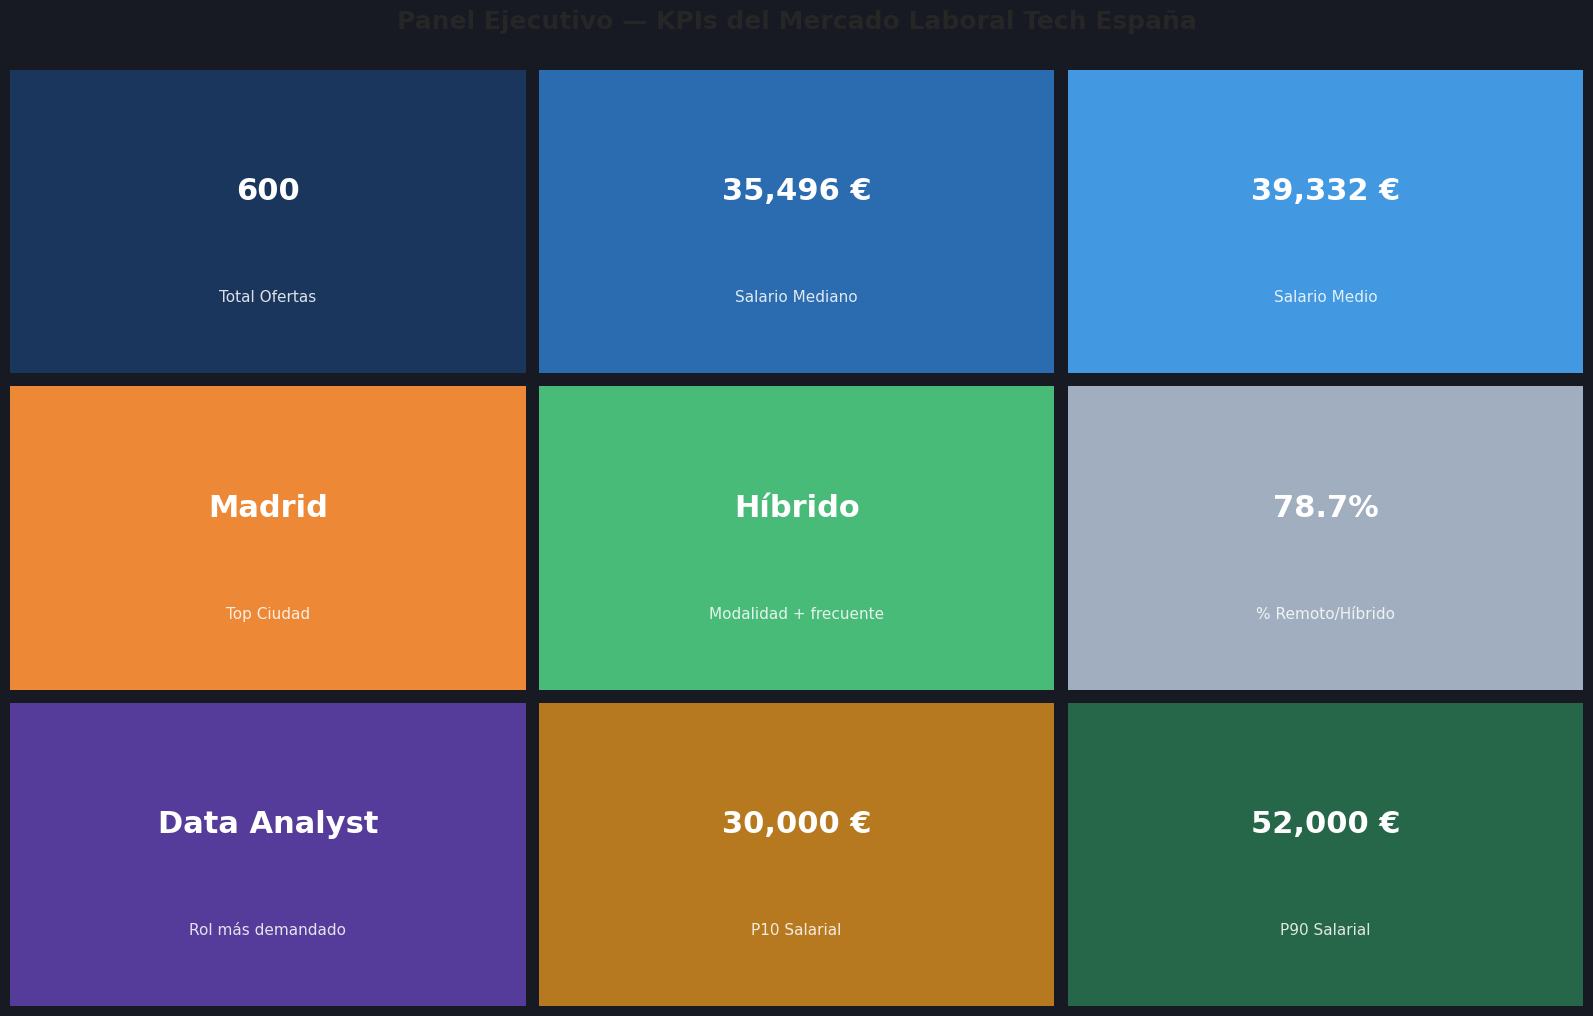

✅ Panel KPIs generado.


In [14]:
# ============================================================
# BLOQUE 7: RESUMEN EJECUTIVO — PANEL KPIs
# ============================================================

sal_col = 'salary_clean' if 'salary_clean' in df_sal.columns else 'salary'

# Calcular KPIs
kpis = {
    'Total Ofertas': f"{len(df):,}",
    'Salario Mediano': f"{df_sal[sal_col].median():,.0f} €",
    'Salario Medio': f"{df_sal[sal_col].mean():,.0f} €",
    'Top Ciudad': df[city_col].value_counts().index[0] if city_col else 'N/D',
    'Modalidad + frecuente': df['remote_modality'].value_counts().index[0] if 'remote_modality' in df.columns else 'N/D',
    '% Remoto/Híbrido': f"{(df['remote_modality'].isin(['Remoto','Híbrido']).mean()*100):.1f}%" if 'remote_modality' in df.columns else 'N/D',
    'Rol más demandado': df['job_title'].value_counts().index[0] if 'job_title' in df.columns else 'N/D',
    'P10 Salarial': f"{df_sal[sal_col].quantile(0.1):,.0f} €",
    'P90 Salarial': f"{df_sal[sal_col].quantile(0.9):,.0f} €",
}

fig_kpi, axes_kpi = plt.subplots(3, 3, figsize=(16, 10))
fig_kpi.suptitle('Panel Ejecutivo — KPIs del Mercado Laboral Tech España',
                 fontsize=18, fontweight='bold', y=1.01)
fig_kpi.patch.set_facecolor(PALETA['dark'])

card_colors = [PALETA['primary'], PALETA['secondary'], PALETA['accent'],
               PALETA['warm'], PALETA['success'], PALETA['muted'],
               '#553C9A', '#B7791F', '#276749']

for ax, (label, value), color in zip(axes_kpi.flatten(), kpis.items(), card_colors):
    ax.set_facecolor(color)
    ax.text(0.5, 0.60, value, ha='center', va='center', fontsize=22,
            fontweight='bold', color='white', transform=ax.transAxes)
    ax.text(0.5, 0.25, label, ha='center', va='center', fontsize=11,
            color='white', alpha=0.85, transform=ax.transAxes)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout(pad=0.8)
plt.savefig('images/07_panel_kpis.png', dpi=200, bbox_inches='tight',
            facecolor=PALETA['dark'])
plt.show()
print("✅ Panel KPIs generado.")

In [ ]:
# ============================================================
# INVENTARIO DE ARCHIVOS EXPORTADOS
# ============================================================
archivos = sorted(os.listdir('images'))
print(f"\n📁 Total de gráficos exportados: {len(archivos)}\n")
for f in archivos:
    size = os.path.getsize(f'images/{f}') / 1024
    print(f"  ✅ images/{f:<45}  ({size:.0f} KB)")

print("\n🎉 Análisis completado.")
print("   → Todos los gráficos disponibles en alta calidad (200 DPI) en ./images/")


---

## 📋 Conclusiones Analíticas

### Distribución de Vacantes
- **Madrid y Barcelona** concentran la mayoría de las ofertas tech del mercado español.
- El modelo **híbrido** es la modalidad predominante, superando al trabajo presencial y remoto.
- La demanda se concentra en perfiles **Mid-level**, seguida de Junior y Senior.

### Análisis Salarial
- Existe una **diferencia estadísticamente significativa** (Kruskal-Wallis) entre los salarios por seniority.
- Los perfiles **remotos** tienden a ofrecer salarios ligeramente superiores.
- La **experiencia** explica parcialmente la variación salarial (regresión OLS).

### Stack Tecnológico
- **Python** y **SQL** son las skills con mayor penetración en ofertas.
- Existe una brecha positiva (*gap* wanted > used) en tecnologías cloud como **AWS** y contenedores como **Docker**.
- Las skills de mayor impacto salarial son las de infraestructura y big data.

### Recomendaciones para DataTalent Solutions
1. Priorizar búsqueda de perfiles Python/SQL para cubrir la mayor demanda.
2. Los candidatos con skills cloud (AWS, Docker) pueden negociar salarios superiores.
3. El modelo híbrido es el nuevo estándar: incluirlo como criterio de búsqueda preferente.

---
*Análisis generado con datos de `02_cleaning.ipynb` · DataTalent Solutions S.L. · 2025*
